# 05 — Correlation Analysis

Full-period correlation matrix, crisis vs calm conditional correlations, and pair trade deep dives.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', '..')))

import pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from energy_workbook.config import ALL_TICKERS, EQUITY_TICKERS, REGIME_NAMES, PAIRS

VIZ = os.path.abspath(os.path.join('..', 'visualization'))
DATA = os.path.abspath(os.path.join('..', 'data'))

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.titlesize': 14,
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#CCCCCC', 'axes.grid': True,
    'grid.alpha': 0.3, 'legend.fontsize': 9,
})
MC_COLORS = ['#002B5C','#1A3C6E','#4A86C8','#0070C0','#C89600',
             '#E06C00','#C00000','#008000','#7030A0','#666666']
cmap_rg = LinearSegmentedColormap.from_list('rg', ['#C00000','#FFFFFF','#006100'])

def savefig(fig, name, dpi=180):
    fig.savefig(os.path.join(VIZ, name), dpi=dpi, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    print(f'  saved {name}')

cache_path = os.path.abspath(os.path.join('..', '..', 'data_cache.pkl'))
with open(cache_path, 'rb') as f:
    D = pickle.load(f)
MASTER = D['master']; LOG_RET = D['log_returns']
print('Data loaded')

Data loaded


## 5.1 Full-Period Correlation Matrix

  saved 03_correlation_heatmap.png


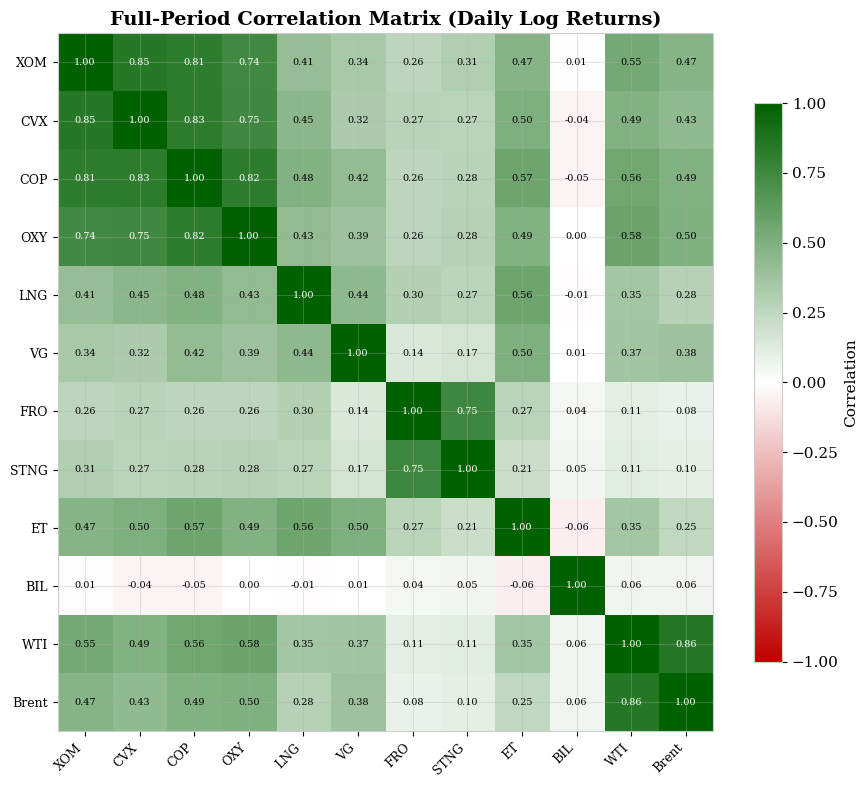

In [2]:
corr_tickers = [t for t in ALL_TICKERS + ['WTI', 'Brent'] if t in LOG_RET.columns]
corr_df = LOG_RET[corr_tickers].dropna().corr()
corr_df.to_csv(os.path.join(DATA, 'correlation_matrix.csv'))

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr_df.values, cmap=cmap_rg, vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_df.columns)))
ax.set_yticks(range(len(corr_df.index)))
ax.set_xticklabels(corr_df.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_df.index, fontsize=9)
for i in range(len(corr_df)):
    for j in range(len(corr_df)):
        v = corr_df.values[i, j]
        c = 'white' if abs(v) > 0.6 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color=c)
plt.colorbar(im, ax=ax, shrink=0.8, label='Correlation')
ax.set_title('Full-Period Correlation Matrix (Daily Log Returns)', fontweight='bold')
fig.tight_layout()
savefig(fig, '03_correlation_heatmap.png')
plt.show()

## 5.2 Crisis vs Calm Conditional Correlations

In [3]:
# Rebuild regime for conditioning
vix = MASTER.get('VIX', pd.Series(dtype=float))
ovx = MASTER.get('OVX', pd.Series(dtype=float))
wti = MASTER.get('WTI', pd.Series(dtype=float))
s2s10 = MASTER.get('Spread_2s10s', pd.Series(dtype=float))
bev = MASTER.get('T10YIE', pd.Series(dtype=float))
bws = MASTER.get('Brent_WTI_Spread', pd.Series(dtype=float))

regime = pd.Series(0, index=MASTER.index, dtype=int)
for i in range(len(MASTER)):
    v = vix.iloc[i] if i < len(vix) else np.nan
    o = ovx.iloc[i] if i < len(ovx) else np.nan
    s = s2s10.iloc[i] if i < len(s2s10) else np.nan
    w = wti.iloc[i] if i < len(wti) else np.nan
    b = bev.iloc[i] if i < len(bev) else np.nan
    bw_v = bws.iloc[i] if i < len(bws) else np.nan
    if pd.isna(v): continue
    ovx_90 = ovx.iloc[:i+1].quantile(0.9) if i > 10 and not pd.isna(o) else 50
    wti_80 = wti.iloc[:i+1].quantile(0.8) if i > 10 and not pd.isna(w) else 80
    if (not pd.isna(o) and o > ovx_90) or (v > 30 and not pd.isna(bw_v) and bw_v > 5):
        regime.iloc[i] = 3
    elif not pd.isna(s) and s < 0 and v > 25:
        regime.iloc[i] = 4
    elif not pd.isna(w) and w > wti_80 and not pd.isna(b) and b > 2.5 and v < 30:
        regime.iloc[i] = 2
    elif v < 20 and (pd.isna(o) or o < 30) and (pd.isna(s) or s > 0):
        regime.iloc[i] = 1

crisis_corr = LOG_RET[corr_tickers][regime == 3].dropna().corr() if (regime == 3).sum() > 30 else corr_df.copy()
calm_corr = LOG_RET[corr_tickers][regime == 1].dropna().corr() if (regime == 1).sum() > 30 else corr_df.copy()

print(f'Crisis days: {(regime==3).sum()}, Calm days: {(regime==1).sum()}')

Crisis days: 156, Calm days: 92


In [ ]:
# Side-by-side crisis vs calm
eq_only = [t for t in EQUITY_TICKERS if t in corr_df.index]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Crisis
cc = crisis_corr.loc[eq_only, eq_only]
im1 = ax1.imshow(cc.values, cmap=cmap_rg, vmin=-1, vmax=1, aspect='auto')
ax1.set_xticks(range(len(eq_only))); ax1.set_yticks(range(len(eq_only)))
ax1.set_xticklabels(eq_only, rotation=45, ha='right', fontsize=9)
ax1.set_yticklabels(eq_only, fontsize=9)
for i in range(len(eq_only)):
    for j in range(len(eq_only)):
        v = cc.values[i, j]; c = 'white' if abs(v) > 0.6 else 'black'
        ax1.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8, color=c)
ax1.set_title('Geopolitical Crisis Correlations', fontweight='bold', color='#C00000')

# Calm
cm = calm_corr.loc[eq_only, eq_only]
im2 = ax2.imshow(cm.values, cmap=cmap_rg, vmin=-1, vmax=1, aspect='auto')
ax2.set_xticks(range(len(eq_only))); ax2.set_yticks(range(len(eq_only)))
ax2.set_xticklabels(eq_only, rotation=45, ha='right', fontsize=9)
ax2.set_yticklabels(eq_only, fontsize=9)
for i in range(len(eq_only)):
    for j in range(len(eq_only)):
        v = cm.values[i, j]; c = 'white' if abs(v) > 0.6 else 'black'
        ax2.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8, color=c)
ax2.set_title('Risk-On / Calm Correlations', fontweight='bold', color='#006100')

fig.suptitle('Correlation Regime Shift: Crisis vs Calm', fontweight='bold', fontsize=16, y=1.02)
fig.tight_layout()
savefig(fig, '24_crisis_vs_calm_correlation.png')
plt.show()

## 5.3 Pair Trade Z-Scores

In [4]:
pair_data = {}
for ta, tb, label in PAIRS:
    if ta in MASTER.columns and tb in MASTER.columns:
        pa, pb = MASTER[ta].dropna(), MASTER[tb].dropna()
        common = pa.index.intersection(pb.index)
        if len(common) > 60:
            spread = np.log(pa[common]) - np.log(pb[common])
            rm = spread.rolling(60).mean()
            rs = spread.rolling(60).std()
            pair_data[f'{ta}/{tb}'] = {
                'z': (spread - rm) / rs,
                'spread': spread,
                'label': label,
            }

print(f'Computed {len(pair_data)} pair trades')

Computed 5 pair trades


  saved 09_pair_trade_zscores.png


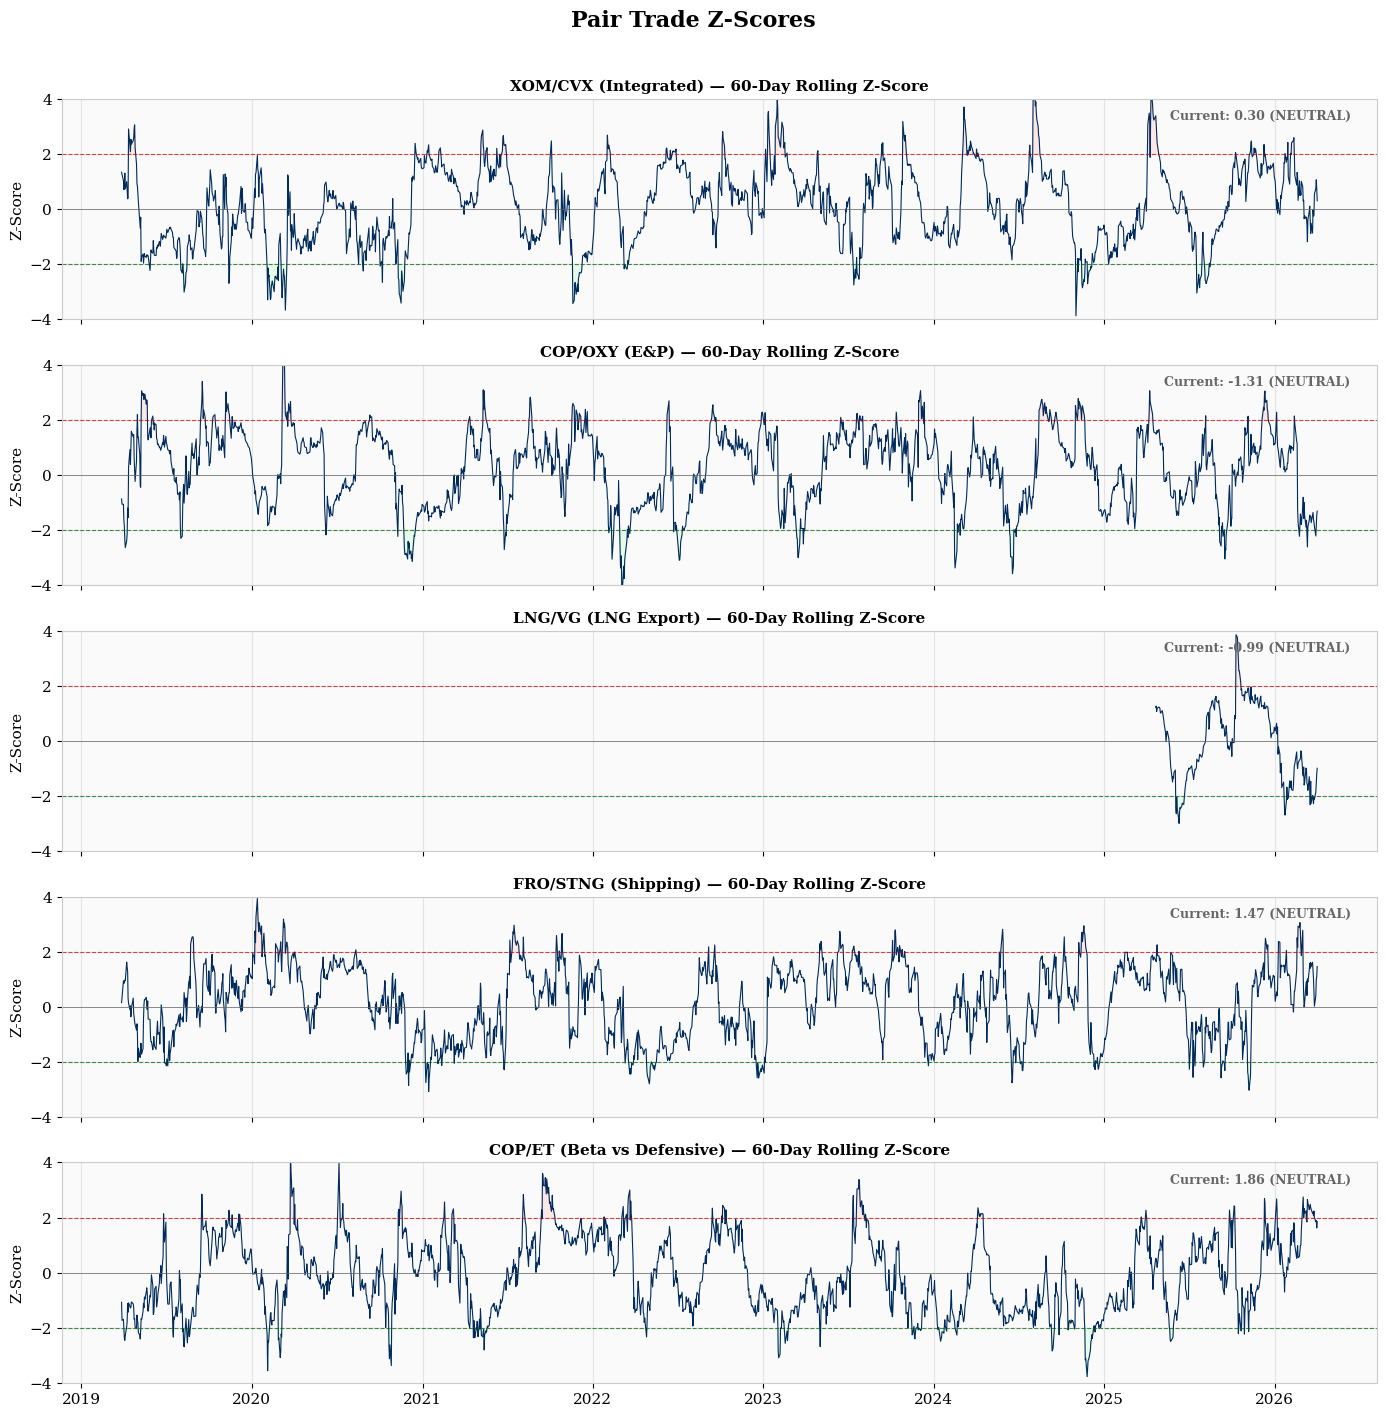

In [5]:
n_p = len(pair_data)
fig, axes = plt.subplots(n_p, 1, figsize=(14, 2.8 * n_p), sharex=True)
if n_p == 1: axes = [axes]

for ax_i, (pn, pd_d) in zip(axes, pair_data.items()):
    z = pd_d['z'].dropna()
    ax_i.plot(z.index, z.values, color='#002B5C', linewidth=0.8)
    ax_i.axhline(2, color='#C00000', linewidth=0.8, linestyle='--', alpha=0.7)
    ax_i.axhline(-2, color='#006100', linewidth=0.8, linestyle='--', alpha=0.7)
    ax_i.axhline(0, color='#666', linewidth=0.5)
    ax_i.fill_between(z.index, 2, z.values, where=z.values > 2, color='#FFD6D6', alpha=0.5)
    ax_i.fill_between(z.index, -2, z.values, where=z.values < -2, color='#D6FFD6', alpha=0.5)
    ax_i.set_ylabel('Z-Score')
    ax_i.set_title(f"{pn} ({pd_d['label']}) — 60-Day Rolling Z-Score", fontweight='bold', fontsize=11)
    ax_i.set_ylim(-4, 4)
    current_z = z.iloc[-1]
    signal = 'SHORT' if current_z > 2 else 'LONG' if current_z < -2 else 'NEUTRAL'
    ax_i.annotate(f'Current: {current_z:.2f} ({signal})', xy=(0.98, 0.95),
                  xycoords='axes fraction', ha='right', va='top', fontsize=9,
                  fontweight='bold', color='#C00000' if current_z > 2 else '#006100' if current_z < -2 else '#666')

fig.suptitle('Pair Trade Z-Scores', fontweight='bold', fontsize=16, y=1.01)
fig.tight_layout()
savefig(fig, '09_pair_trade_zscores.png')
plt.show()

## 5.4 Pair Deep Dives

  saved 21_cop_vs_oxy_scatter.png


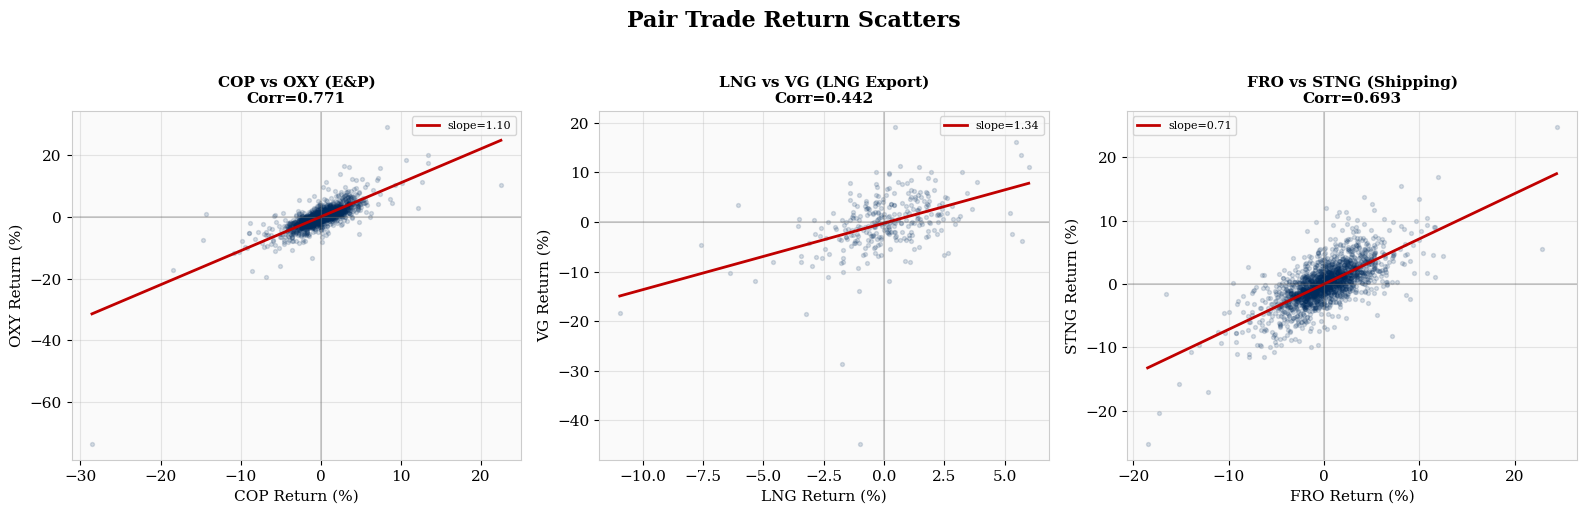

In [6]:
# COP vs OXY scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs_deep = [('COP','OXY','E&P'), ('LNG','VG','LNG Export'), ('FRO','STNG','Shipping')]
filenames = ['21_cop_vs_oxy_scatter.png', '22_lng_vs_vg.png', '23_fro_vs_stng.png']

for ax, (ta, tb, label), fname in zip(axes, pairs_deep, filenames):
    ra = LOG_RET.get(ta, pd.Series(dtype=float)).dropna()
    rb_s = LOG_RET.get(tb, pd.Series(dtype=float)).dropna()
    common = ra.index.intersection(rb_s.index)
    if len(common) > 30:
        ax.scatter(ra[common].values * 100, rb_s[common].values * 100,
                   alpha=0.15, s=8, color='#002B5C')
        # Regression line
        x, y = ra[common].values, rb_s[common].values
        X = np.column_stack([np.ones(len(x)), x])
        b = np.linalg.lstsq(X, y, rcond=None)[0]
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line * 100, (b[0] + b[1] * x_line) * 100, color='#C00000',
                linewidth=2, label=f'slope={b[1]:.2f}')
        corr = np.corrcoef(x, y)[0, 1]
        ax.set_title(f'{ta} vs {tb} ({label})\nCorr={corr:.3f}', fontweight='bold', fontsize=11)
        ax.set_xlabel(f'{ta} Return (%)')
        ax.set_ylabel(f'{tb} Return (%)')
        ax.legend(fontsize=8)
        ax.axhline(0, color='#333', linewidth=0.3)
        ax.axvline(0, color='#333', linewidth=0.3)

fig.suptitle('Pair Trade Return Scatters', fontweight='bold', fontsize=16, y=1.02)
fig.tight_layout()
# Save individual scatter plots too
savefig(fig, '21_cop_vs_oxy_scatter.png')
plt.show()